Import required libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

Build Dataframe and split training/testing data

In [2]:
# Read in data
iris = pd.read_csv(
  "iris.data",
  header=None,
  names=["sepal_length", "sepal_width", "petal_length", "petal_width", "species"]
)

# Separate input and output data
X = iris.iloc[:, :4]
y = iris["species"]

# Do a random, equal representation split (easy reproduction)
X_train, X_test, y_train, y_test = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

X_train.head()

,sepal_length,sepal_width,petal_length,petal_width
8,4.4,2.9,1.4,0.2
106,4.9,2.5,4.5,1.7
76,6.8,2.8,4.8,1.4
9,4.9,3.1,1.5,0.1
89,5.5,2.5,4.0,1.3


Plot each feature relationship on a Scatterplot

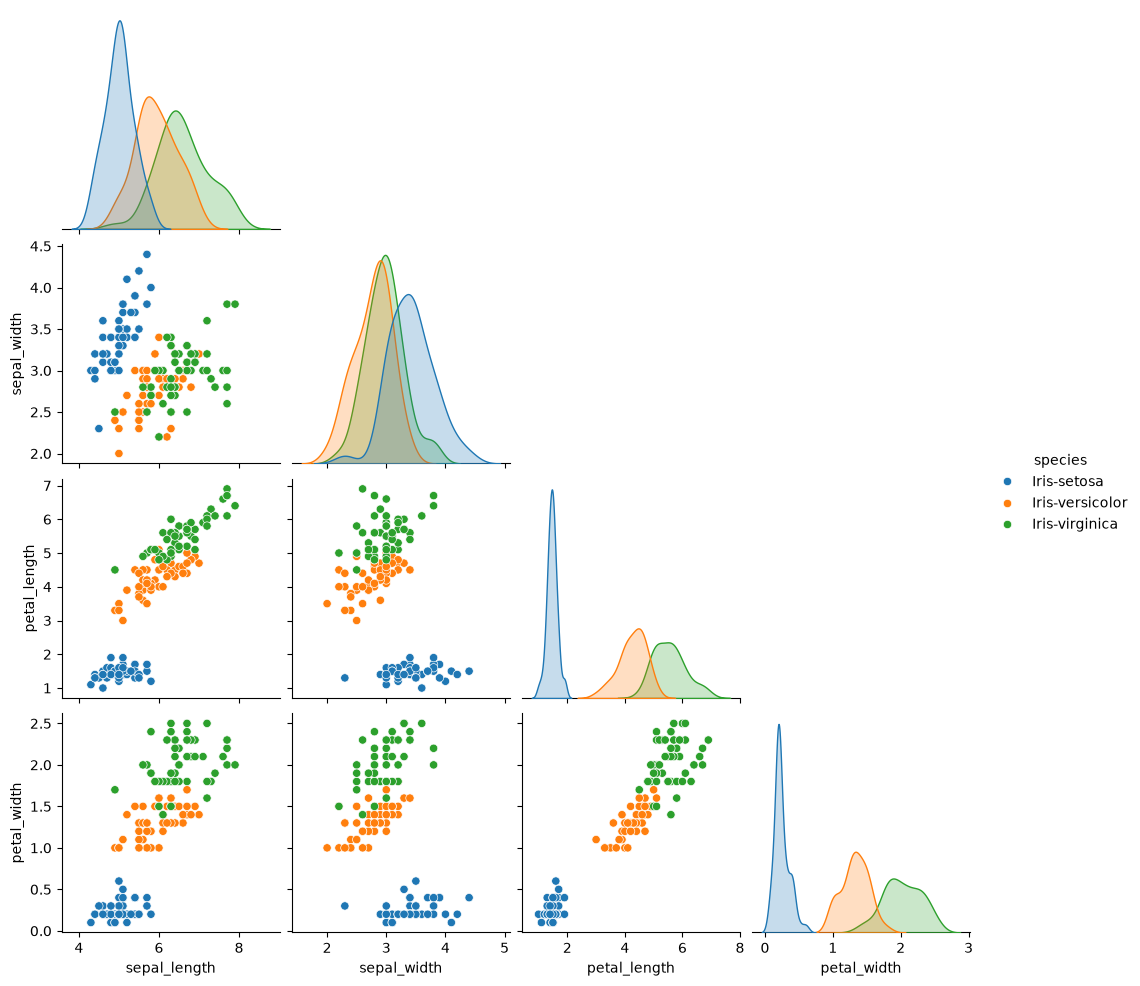

In [3]:
sns.pairplot(iris, hue="species", corner=True)
plt.show()

Run the pipeline and evaluate results

In [4]:
# Simple Logistic Regression only pipeline
pipeline = Pipeline([
  ("classifier", LogisticRegression(max_iter=500))
])

# Train model on training data
pipeline.fit(X_train, y_train)

# Generate predictions on test data
y_pred = pipeline.predict(X_test)

# Compare accuracy between prediction and actual
test_accuracy = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {test_accuracy:.2%}")

Test accuracy: 96.67%
